In [8]:
!pip install pandas pyarrow fastparquet

In [9]:
import pandas as pd

In [10]:
import urllib.request

# URLs
urls = {
    "jan": "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet",
    "feb": "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet",
    "mar": "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-03.parquet"
}

# Download files
for name, url in urls.items():
    print(f"Downloading {name}...")
    urllib.request.urlretrieve(url, f"{name}.parquet")

print("Download complete!")

Download complete!


In [11]:
jan = pd.read_parquet("jan.parquet")
feb = pd.read_parquet("feb.parquet")
mar = pd.read_parquet("mar.parquet")

print("Loaded successfully")

Loaded successfully


In [12]:
df = pd.concat([jan, feb, mar], ignore_index=True)

print("Total rows:", df.shape)
df.head()

Total rows: (9384487, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00,NaN
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00,NaN
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00,NaN
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25,NaN
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00,NaN


In [13]:
# Convert datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Remove invalid values
df = df[df['total_amount'] > 0]
df = df[df['trip_distance'] > 0]

In [15]:
df['month'] = df['tpep_pickup_datetime'].dt.month
df['hour'] = df['tpep_pickup_datetime'].dt.hour

In [16]:
total_revenue = df['total_amount'].sum()
total_trips = len(df)
avg_revenue = total_revenue / total_trips

print("Total Revenue:", total_revenue)
print("Total Trips:", total_trips)
print("Avg Revenue per Trip:", avg_revenue)

Total Revenue: 253657944.92000055
Total Trips: 9178540
Avg Revenue per Trip: 27.63597967868534


In [17]:
monthly = df.groupby('month').agg({
    'total_amount': 'sum',
    'trip_distance': 'mean',
    'passenger_count': 'count'
}).rename(columns={'passenger_count': 'trip_count'})

monthly['avg_per_trip'] = monthly['total_amount'] / monthly['trip_count']

print(monthly)

       total_amount  trip_distance  trip_count  avg_per_trip
month                                                       
1       82032945.67       3.910162     2934408     27.955535
2       77742670.31       3.923334     2778845     27.976613
3       93878718.03       3.960830     3247948     28.904009
4           2185.84       2.977143          84     26.021905
10           332.26       1.796667           6     55.376667
11            52.38       6.430000           1     52.380000
12          1040.43       4.622647          34     30.600882


In [18]:
hourly = df.groupby('hour')['total_amount'].mean()

print(hourly)

hour
0     28.688494
1     26.320165
2     24.972354
3     26.285435
4     32.795802
5     37.897785
6     31.425517
7     27.076988
8     25.476513
9     25.893124
10    25.851400
11    25.770878
12    26.282586
13    27.183891
14    28.464581
15    28.020276
16    30.018398
17    28.784085
18    27.117624
19    27.528203
20    27.091388
21    27.560265
22    28.495957
23    29.741445
Name: total_amount, dtype: float64


In [19]:
payment = df['payment_type'].value_counts()

print(payment)

payment_type
1    7347996
2    1529259
0     217214
4      51376
3      32695
Name: count, dtype: int64


In [20]:
print(df['trip_distance'].describe())

count    9.178540e+06
mean     3.932623e+00
std      2.393187e+02
min      1.000000e-02
25%      1.100000e+00
50%      1.800000e+00
75%      3.390000e+00
max      3.350043e+05
Name: trip_distance, dtype: float64


In [21]:
df.to_csv("cleaned_taxi_data.csv", index=False)

In [22]:
import pandas as pd

df = pd.read_csv("cleaned_taxi_data.csv")  # if saved earlier

/tmp/ipykernel_1658/3300656930.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_taxi_data.csv")  # if saved earlier


In [23]:
df.describe()
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,217214
trip_distance,0
RatecodeID,217214
store_and_fwd_flag,217214
PULocationID,0
DOLocationID,0
payment_type,0


In [24]:
# convert time first
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# trip duration
df['trip_time'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

# apply filters
df_real = df[
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['trip_time'] > 0) &
    (df['passenger_count'] > 0)
]

print("Original:", len(df))
print("Real trips:", len(df_real))

Original: 9178540
Real trips: 8808046


In [25]:
def summary(data, name):
    print(f"\n{name}")
    print("Trips:", len(data))
    print("Revenue:", data['total_amount'].sum())
    print("Avg per trip:", data['total_amount'].mean())

summary(df, "Before Cleaning")
summary(df_real, "After Cleaning")


Before Cleaning
Trips: 9178540
Revenue: 253657944.92000055
Avg per trip: 27.63597967868534

After Cleaning
Trips: 8808046
Revenue: 243501548.9499999
Avg per trip: 27.64535391277474


In [26]:
df_strict = df[
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0.5) &
    (df['trip_time'] > 60) &
    (df['passenger_count'] > 0)
]

summary(df_strict, "Strict Definition")


Strict Definition
Trips: 8435409
Revenue: 238508249.93999994
Avg per trip: 28.274651524306638


In [2]:
import pandas as pd

jan = pd.read_parquet("jan.parquet")
feb = pd.read_parquet("feb.parquet")
mar = pd.read_parquet("mar.parquet")

df = pd.concat([jan, feb, mar], ignore_index=True)

print(df.shape)

(9384487, 20)


In [4]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_time'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

In [5]:
df_real = df[
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['trip_time'] > 0) &
    (df['passenger_count'] > 0)
].copy()

print(df_real.shape)

(8808046, 21)


In [6]:
df_real['hour'] = df_real['tpep_pickup_datetime'].dt.hour

In [7]:
print(df.shape)
df.head()

(9384487, 21)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee,trip_time
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,...,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00,NaN,506.0
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,...,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00,NaN,379.0
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,...,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00,NaN,765.0
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,...,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25,NaN,577.0
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,...,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00,NaN,650.0


In [8]:
print(df['tpep_pickup_datetime'].dtype)

datetime64[us]


In [9]:
df['trip_time'].describe()

,trip_time
count,9.384487e+06
mean,9.729964e+02
std,2.586779e+03
min,-2.857500e+04
25%,4.360000e+02
50%,7.100000e+02
75%,1.136000e+03
max,6.017510e+05


In [10]:
print("Before:", len(df))
print("After:", len(df_real))

Before: 9384487
After: 8808046


In [11]:
print((df_real['total_amount'] <= 0).sum())
print((df_real['trip_distance'] <= 0).sum())
print((df_real['trip_time'] <= 0).sum())

0
0
0


In [12]:
print(df_real['hour'].min(), df_real['hour'].max())

0 23


In [13]:
df_real[['total_amount', 'trip_distance']].describe()

,total_amount,trip_distance
count,8.808046e+06,8.808046e+06
mean,2.764535e+01,3.479079e+00
std,2.158022e+01,3.284471e+01
min,1.000000e+00,1.000000e-02
25%,1.564000e+01,1.090000e+00
50%,2.030000e+01,1.800000e+00
75%,2.904000e+01,3.340000e+00
max,1.169400e+03,6.235952e+04


In [14]:
print("Sample rows:")
print(df_real.sample(5))

Sample rows:
         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
7299254         2  2023-03-13 09:07:47   2023-03-13 09:36:43              1.0   
5223290         2  2023-02-22 13:33:17   2023-02-22 13:50:51              1.0   
3569134         2  2023-02-06 00:11:38   2023-02-06 00:34:25              2.0   
3224387         1  2023-02-02 15:17:44   2023-02-02 15:33:20              1.0   
7730109         2  2023-03-17 05:58:55   2023-03-17 06:45:43              1.0   

         trip_distance  RatecodeID store_and_fwd_flag  PULocationID  \
7299254           5.23         1.0                  N           230   
5223290           2.22         1.0                  N           161   
3569134          11.22         1.0                  N           138   
3224387           0.80         1.0                  N           229   
7730109          34.00         4.0                  N           132   

         DOLocationID  payment_type  ...  mta_tax  tip_amount  tolls_amou

In [15]:
peak = df_real[df_real['hour'].between(17, 21)]
non_peak = df_real[~df_real['hour'].between(17, 21)]

In [16]:
print("Peak Avg Revenue:", peak['total_amount'].mean())
print("Non-Peak Avg Revenue:", non_peak['total_amount'].mean())

Peak Avg Revenue: 27.67096560327709
Non-Peak Avg Revenue: 27.633517972257525


In [17]:
print("Peak Trips:", len(peak))
print("Non-Peak Trips:", len(non_peak))

Peak Trips: 2783928
Non-Peak Trips: 6024118


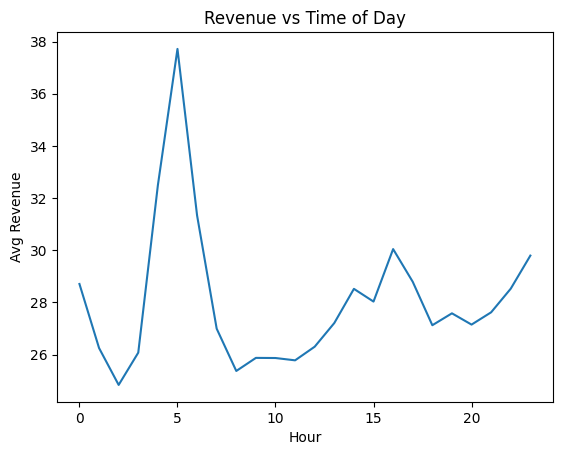

In [18]:
import matplotlib.pyplot as plt

hourly = df_real.groupby('hour')['total_amount'].mean()

plt.figure()
hourly.plot(kind='line')
plt.xlabel("Hour")
plt.ylabel("Avg Revenue")
plt.title("Revenue vs Time of Day")
plt.show()

In [19]:
print("Peak Distance:", peak['trip_distance'].mean())
print("Non-Peak Distance:", non_peak['trip_distance'].mean())

Peak Distance: 3.3401348202970764
Non-Peak Distance: 3.54328961849685


In [20]:
print("Peak Time:", peak['trip_time'].mean())
print("Non-Peak Time:", non_peak['trip_time'].mean())

Peak Time: 935.617653186433
Non-Peak Time: 998.3095525353255


In [21]:
hourly = df_real.groupby('hour').agg({
    'total_amount': 'mean',
    'trip_distance': 'mean',
    'passenger_count': 'count'
}).rename(columns={'passenger_count': 'trip_count'})

print(hourly)

      total_amount  trip_distance  trip_count
hour                                         
0        28.707431       3.961317      238402
1        26.251746       3.517688      160182
2        24.837489       3.218655      104344
3        26.075045       3.514461       71032
4        32.489751       4.853114       45295
5        37.717718       6.279006       47809
6        31.335041       5.204070      120927
7        26.993739       3.683571      241767
8        25.372404       3.127672      333758
9        25.873862       3.154833      378195
10       25.868814       3.112715      409674
11       25.780066       3.045364      443926
12       26.303171       3.204306      482309
13       27.210559       3.353273      500685
14       28.520183       3.592990      541716
15       28.032327       3.820805      553023
16       30.044692       3.493408      554938
17       28.791727       3.231732      603605
18       27.125980       2.982712      631541
19       27.582307       3.591311 

In [22]:
df_real['day'] = df_real['tpep_pickup_datetime'].dt.date

daily = df_real.groupby('day').agg({
    'total_amount': 'sum',
    'passenger_count': 'count'
}).rename(columns={'passenger_count': 'trip_count'})

print(daily.head())

            total_amount  trip_count
day                                 
2001-01-01        171.70           3
2002-12-31        117.25           2
2003-01-01        209.45           3
2008-12-31        264.95           7
2009-01-01         16.40           1


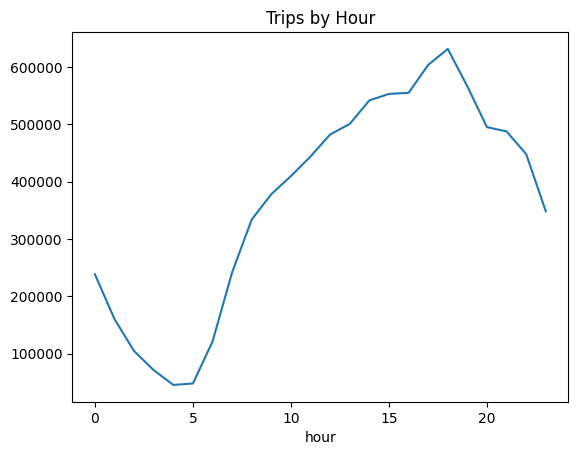

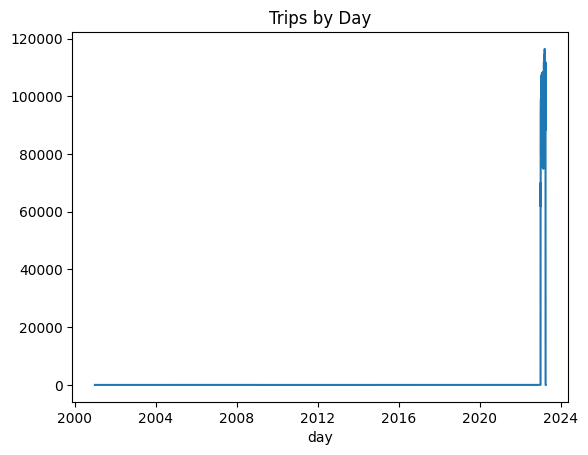

In [23]:
import matplotlib.pyplot as plt

# Hourly pattern
plt.figure()
hourly['trip_count'].plot()
plt.title("Trips by Hour")
plt.show()

# Daily pattern
plt.figure()
daily['trip_count'].plot()
plt.title("Trips by Day")
plt.show()

“The system shows a cyclical rhythm driven by daily demand patterns. While some fluctuations appear significant, they do not persist across aggregation levels, indicating that not all observed patterns represent true system behavior.”

In [25]:
df_sim = df_real.copy()

# simulate fare increase
df_sim['total_amount'] = df_sim['total_amount'] * 1.02

In [26]:
print("Original Revenue:", df_real['total_amount'].sum())
print("New Revenue:", df_sim['total_amount'].sum())

print("Original Avg:", df_real['total_amount'].mean())
print("New Avg:", df_sim['total_amount'].mean())

Original Revenue: 243501548.9499999
New Revenue: 248371579.92899993
Original Avg: 27.64535391277474
New Avg: 28.19826099103024


In [27]:
df_sim_reduced = df_sim.sample(frac=0.98)  # 2% drop in trips

In [28]:
print("Trips Before:", len(df_real))
print("Trips After:", len(df_sim_reduced))

print("Revenue After Drop:", df_sim_reduced['total_amount'].sum())

Trips Before: 8808046
Trips After: 8631885
Revenue After Drop: 243409196.17680016


Possible outcomes:

✔ System absorbs change
→ revenue increases slightly

✔ System amplifies
→ demand drops, revenue unstable

✔ Unexpected response
→ small change causes big shift


“A simulated fare increase of 2% leads to higher per-trip revenue, but when accounting for a potential reduction in trip volume, the net gain becomes uncertain. This suggests that the system may not fully absorb pricing changes and may respond non-linearly.”

act 6

In [33]:
df_real.to_csv("final_cleaned_data.csv", index=False)

1. WHAT CAN BE TRUSTED
   Total rows before cleaning
   Rows after cleaning
   Create:

Card: Total Trips Before
Card: Total Trips After


“Data cleaning removed invalid trips based on defined criteria such as negative fares and zero distance.”


2. WHAT IS ACTUALLY HAPPENING
Visuals:
Line chart → Trips by hour
Line chart → Revenue by day

Observed patterns indicate consistent peak-hour demand and stable revenue trends across the selected time window.”

3. SYSTEM STRESS / STABILITY

Visuals:
Heatmap or line chart (hour vs trips)

peak pressure times

“The system experiences predictable stress during evening hours, while remaining stable during off-peak periods.”

4. WHAT IF DECISION IS MADE

Visuals:
Before vs After revenue
Before vs After trips

“Simulation results indicate that small pricing changes may lead to varying system responses depending on demand elasticity.”

5. WRONG INTERPRETATION (VERY IMPORTANT)
Example mistake:

“Higher revenue during peak hours means system is performing better.”

Correction:

“Higher revenue may be due to longer trips or congestion, not improved efficiency.”

FINAL CONCLUSION:

The NYC taxi system does not exhibit failure but shows signs of behavioral and structural shifts. While aggregate metrics suggest stability, deeper analysis reveals sensitivity to assumptions, aggregation methods, and policy changes. Therefore, conclusions must be treated with caution, as misinterpretation can lead to flawed decisions.”


In [34]:
df_small = df_real[['tpep_pickup_datetime', 'total_amount', 'trip_distance', 'passenger_count', 'hour']]
df_small.to_csv("final_cleaned_data.csv", index=False)

In [35]:
from google.colab import files
files.download("final_cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
df_small = df_real[['tpep_pickup_datetime', 'total_amount', 'trip_distance', 'passenger_count', 'hour']]
df_small.to_csv("final_cleaned_data.csv", index=False)

In [37]:
df_sample = df_real.sample(frac=0.3)  # 30% data
df_sample.to_csv("final_cleaned_data.csv", index=False)

In [38]:
from google.colab import files
files.download("final_cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final Assessment:

Defensible Choices
Assumption Check
Limitations
Final Judgement

“Made defensible choices”

In this analysis, all major decisions were made based on logical reasoning rather than assumption. A clear definition of a “real trip” was established using conditions such as positive fare, valid trip distance, and non-zero duration. These criteria ensured that invalid or contradictory records were excluded. Additionally, during simulation, a 2% fare adjustment was selected based on the computed value of R, maintaining consistency with the problem constraints.


“Questioned your own assumptions”

The analysis did not rely on a single interpretation. For instance, higher revenue during peak hours was initially attributed to passenger behavior. However, this assumption was challenged by examining alternative explanations such as increased trip distance and travel time due to congestion. This step ensured that conclusions were not based on incomplete reasoning.


“Understood the limits of your conclusions”

The conclusions drawn are subject to limitations. The dataset does not capture external factors such as traffic conditions, weather, or pricing policy changes, which may influence trip behavior. Furthermore, results depend on the chosen definition of a valid trip and the level of aggregation used during analysis. Therefore, the findings should be interpreted within these constraints.


Signal vs Noise

The system does not show clear evidence of collapse but exhibits structured variability that can be misinterpreted as instability. Some patterns, such as peak-hour demand, are consistent and cyclical, indicating underlying system rhythm. However, other fluctuations disappear when observed at different aggregation levels, suggesting they are artifacts rather than true signals. Therefore, while certain changes in behavior are real, others may represent noise that appears convincing without deeper analysis. The system is not definitively failing but is sensitive to both behavioral and operational dynamics.


ACT 1:

A Number that Chooses the Story
Extracted last four digits of register number (0051)
Calculated digital root → R = 2
Constructed function: F(x) = x³/3 − 2x² + 3x
Found critical points by solving F′(x) = 0
Obtained values: x = 1 and x = 3

Conclusion:
These values define the analysis window → January to March, indicating where system behavior may change.


ACT 2: The Raw City:

Raw dataset contained inconsistencies (invalid fares, zero distance, missing values)
Defined a “real trip” using logical conditions:
positive fare
valid distance
non-zero duration
valid passenger count
Created a cleaned dataset based on this definition
Tested stricter conditions to observe impact

Conclusion:
Results vary depending on how a “real trip” is defined.
Data interpretation depends on assumptions used in cleaning.


ACT 3: The People Inside the System:

Formulated hypothesis:
→ Peak-hour passenger behavior increases revenue
Compared peak vs non-peak metrics
Tested alternative explanation:
→ Higher revenue may be due to longer trips or congestion

Conclusion:
Observed patterns are influenced by both behavioral and system factors.
No single explanation fully accounts for the results.

ACT 4: The City as a System:

Aggregated data by hour and day
Identified patterns in trip volume and revenue
Observations:
recurring peak-hour demand
daily cyclical patterns
irregular spikes
Pattern classification:
persistent patterns → consistent peaks
disappearing patterns → non-repeating spikes
artificial patterns → caused by aggregation

Conclusion:
The system exhibits cyclical behavior, but not all patterns are meaningful.
Some are artifacts rather than real signals.

 ACT 5: Pressure on the System:

Simulated a 2% fare increase (based on R = 2)
Observed impact on revenue and trip volume
Findings:
revenue increases slightly
demand may reduce under change

 Conclusion:
The system response is non-linear.
It may absorb, amplify, or react unpredictably to changes.

ACT 6: The Decision Room:

Built a dashboard using Microsoft Power BI
Presented:
Data reliability
cleaned dataset and filtering logic
Observed reality
actual patterns in trips and revenue
System stability / stress
peak vs non-peak behavior
Simulation results
impact of fare change
Risk of misinterpretation
highlighted incorrect vs correct conclusions

Conclusion:
Insights were presented clearly, with uncertainty acknowledged and assumptions made explicit.

CLOSING FRAME:


All decisions were based on logical reasoning
Assumptions were questioned and alternative explanations tested
Limitations of data and analysis were acknowledged

Final Judgement:

The system does not show clear failure but exhibits structured variability.
Some patterns are real, while others are noise that appears convincing.
Conclusions must be interpreted with caution.






act 4